In [ ]:
!pip uninstall -y scikeras scikit-learn
!pip install scikit-learn==1.5.2
!pip install scikeras==0.13.0

Found existing installation: scikeras 0.13.0
Uninstalling scikeras-0.13.0:
  Successfully uninstalled scikeras-0.13.0
Found existing installation: scikit-learn 1.5.2
Uninstalling scikit-learn-1.5.2:
  Successfully uninstalled scikit-learn-1.5.2
  Using cached scikit_learn-1.5.2-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (13 kB)
Using cached scikit_learn-1.5.2-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (12.9 MB)
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
umap-learn 0.5.12 requires scikit-learn>=1.6, but you have scikit-learn 1.5.2 which is incompatible.
hdbscan 0.8.44 requires scikit-learn>=1.6, but you have scikit-learn 1.5.2 which is incompatible.
  Using cached scikeras-0.13.0-py3-none-any.whl.metadata (3.1 kB)
Using cached scikeras-0.13.0-py3-none-any.whl (26 kB)


In [ ]:
#task1
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import fashion_mnist
# Load Fashion-MNIST dataset
(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

In [ ]:
class_names = [
    "T-shirt/Top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle Boot"
]

In [ ]:
print("Fashion-MNIST Dataset Information\n")
print("Training Images Shape :", X_train.shape)
print("Training Labels Shape :", y_train.shape)
print("Testing Images Shape  :", X_test.shape)
print("Testing Labels Shape  :", y_test.shape)
print("\nImage Size :", X_train[0].shape)
print("Number of Classes :", len(np.unique(y_train)))

Fashion-MNIST Dataset Information

Training Images Shape : (60000, 28, 28)
Training Labels Shape : (60000,)
Testing Images Shape  : (10000, 28, 28)
Testing Labels Shape  : (10000,)

Image Size : (28, 28)
Number of Classes : 10


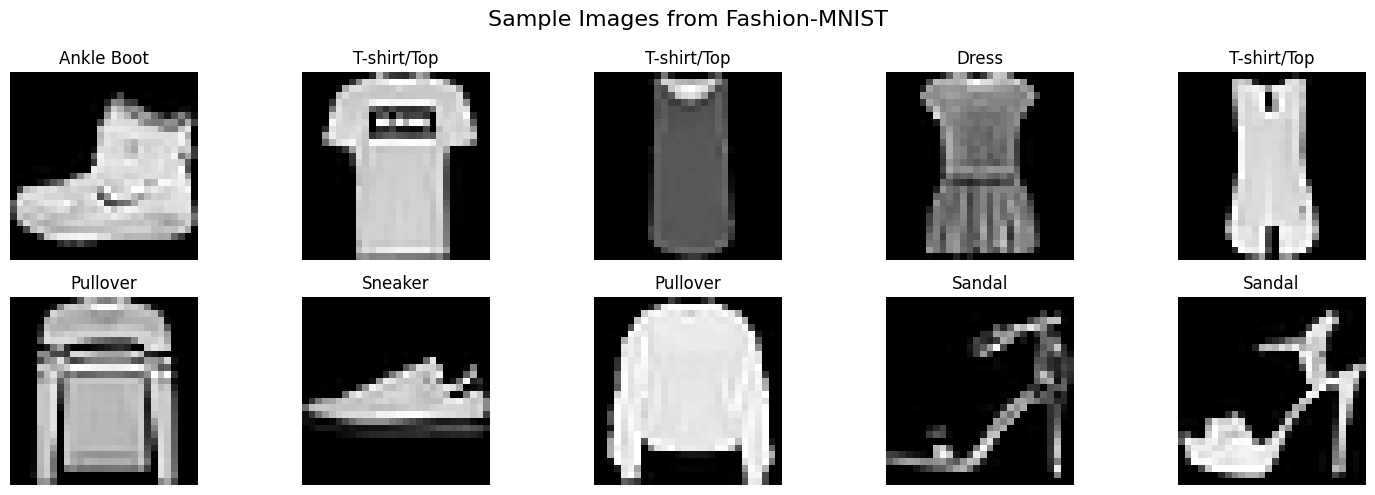

In [ ]:
plt.figure(figsize=(15,5))

for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(X_train[i], cmap="gray")
    plt.title(class_names[y_train[i]])
    plt.axis("off")

plt.suptitle("Sample Images from Fashion-MNIST", fontsize=16)
plt.tight_layout()
plt.show()

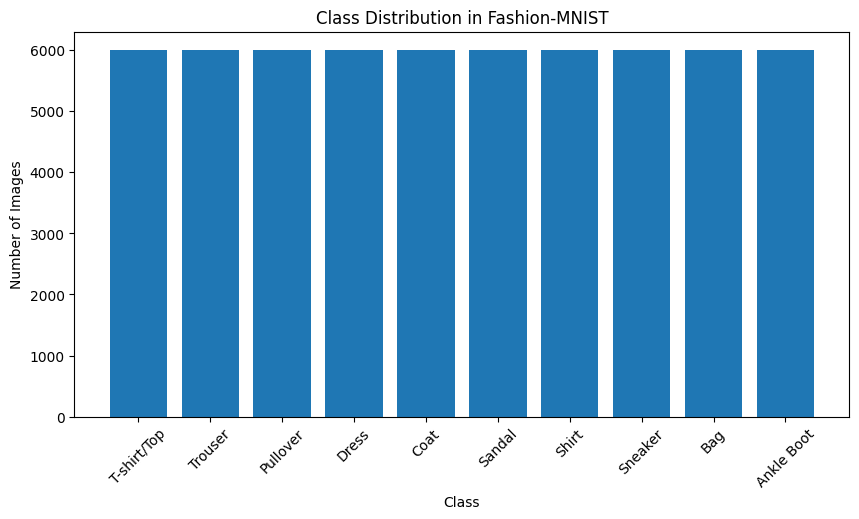

In [ ]:
unique, counts = np.unique(y_train, return_counts=True)

plt.figure(figsize=(10,5))
plt.bar(class_names, counts)

plt.title("Class Distribution in Fashion-MNIST")
plt.xlabel("Class")
plt.ylabel("Number of Images")

plt.xticks(rotation=45)
plt.show()

In [ ]:
#task2
import tensorflow as tf
print("Before Preprocessing")
print("Training Images Shape :", X_train.shape)
print("Testing Images Shape  :", X_test.shape)
print("Training Labels Shape :", y_train.shape)
print("Testing Labels Shape  :", y_test.shape)

X_train = X_train.reshape(60000, 784)
X_test = X_test.reshape(10000, 784)

X_train = X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

y_train = tf.keras.utils.to_categorical(y_train, 10)
y_test = tf.keras.utils.to_categorical(y_test, 10)
print("\nAfter Preprocessing")
print("Training Images Shape :", X_train.shape)
print("Testing Images Shape  :", X_test.shape)
print("Training Labels Shape :", y_train.shape)
print("Testing Labels Shape  :", y_test.shape)

Before Preprocessing
Training Images Shape : (60000, 28, 28)
Testing Images Shape  : (10000, 28, 28)
Training Labels Shape : (60000,)
Testing Labels Shape  : (10000,)

After Preprocessing
Training Images Shape : (60000, 784)
Testing Images Shape  : (10000, 784)
Training Labels Shape : (60000, 10)
Testing Labels Shape  : (10000, 10)


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input

model = Sequential([
    Input(shape=(784,)),
    Dense(128, activation='relu'),
    Dense(64, activation='relu'),
    Dense(10, activation='softmax')
])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Compile the model
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Train the model
history = model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

Epoch 1/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 22s 13ms/step - accuracy: 0.8175 - loss: 0.5140 - val_accuracy: 0.8555 - val_loss: 0.4121
Epoch 2/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.8617 - loss: 0.3822 - val_accuracy: 0.8565 - val_loss: 0.3884
Epoch 3/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.8724 - loss: 0.3432 - val_accuracy: 0.8739 - val_loss: 0.3493
Epoch 4/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8815 - loss: 0.3197 - val_accuracy: 0.8712 - val_loss: 0.3515
Epoch 5/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.8880 - loss: 0.3004 - val_accuracy: 0.8763 - val_loss: 0.3390
Epoch 6/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8924 - loss: 0.2869 - val_accuracy: 0.8801 - val_loss: 0.3450
Epoch 7/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.8987 - loss: 0.2721 - val_accuracy: 0.8903 - val_loss: 0.3167
Epoch 8/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9019 - loss: 0.2604 

In [ ]:
test_loss, test_accuracy = model.evaluate(X_test, y_test)

print(f"\nTest Loss     : {test_loss:.4f}")
print(f"Test Accuracy : {test_accuracy:.4f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8812 - loss: 0.3929

Test Loss     : 0.3929
Test Accuracy : 0.8812


In [ ]:
import numpy as np

y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test, axis=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


In [ ]:
from sklearn.metrics import classification_report

print(classification_report(
    y_true,
    y_pred_classes,
    target_names=class_names
))

              precision    recall  f1-score   support

 T-shirt/Top       0.81      0.83      0.82      1000
     Trouser       0.99      0.97      0.98      1000
    Pullover       0.79      0.82      0.81      1000
       Dress       0.87      0.91      0.89      1000
        Coat       0.81      0.81      0.81      1000
      Sandal       0.99      0.95      0.97      1000
       Shirt       0.71      0.64      0.67      1000
     Sneaker       0.92      0.97      0.94      1000
         Bag       0.97      0.96      0.97      1000
  Ankle Boot       0.96      0.94      0.95      1000

    accuracy                           0.88     10000
   macro avg       0.88      0.88      0.88     10000
weighted avg       0.88      0.88      0.88     10000



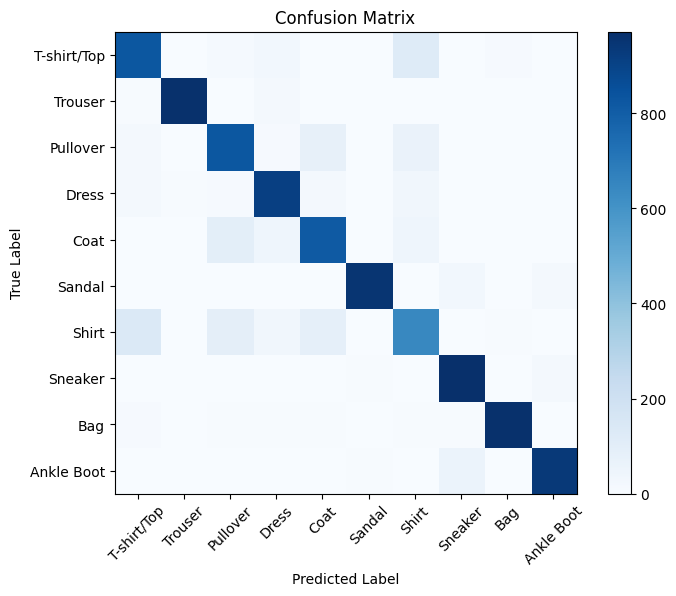

In [ ]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred_classes)

plt.figure(figsize=(8,6))
plt.imshow(cm, cmap='Blues')
plt.title("Confusion Matrix")
plt.colorbar()

plt.xticks(range(10), class_names, rotation=45)
plt.yticks(range(10), class_names)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.show()

In [ ]:
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score

precision = precision_score(y_true, y_pred_classes, average='weighted')
recall = recall_score(y_true, y_pred_classes, average='weighted')
f1 = f1_score(y_true, y_pred_classes, average='weighted')

print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1-Score  : {f1:.4f}")

Precision : 0.8810
Recall    : 0.8812
F1-Score  : 0.8807


In [ ]:
!pip install scikeras

In [ ]:
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam, SGD, RMSprop
from scikeras.wrappers import KerasClassifier
from sklearn.model_selection import RandomizedSearchCV

def create_model(hidden_layers=2,
                 hidden_neurons=128,
                 learning_rate=0.001,
                 optimizer="adam",
                 activation="relu",
                 dropout_rate=0.0):

    model = Sequential()
    model.add(Dense(hidden_neurons,
                    activation=activation,
                    input_shape=(784,)))

    if dropout_rate > 0:
        model.add(Dropout(dropout_rate))

    for i in range(hidden_layers-1):

        model.add(Dense(hidden_neurons,
                        activation=activation))
        if dropout_rate > 0:
            model.add(Dropout(dropout_rate))

    model.add(Dense(10,
                    activation="softmax"))
    if optimizer == "adam":
        opt = Adam(learning_rate=learning_rate)
    elif optimizer == "sgd":
        opt = SGD(learning_rate=learning_rate)
    else:
        opt = RMSprop(learning_rate=learning_rate)
    model.compile(
        optimizer=opt,
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

In [ ]:
classifier = KerasClassifier(
    model=create_model,
    verbose=0
)

In [ ]:
param_dist = {

    "model__hidden_layers":[1,2,3],

    "model__hidden_neurons":[32,64,128,256],

    "model__learning_rate":[0.1,0.01,0.001],

    "batch_size":[16,32,64,128],

    "epochs":[10,20,30],

    "model__optimizer":[
        "sgd",
        "adam",
        "rmsprop"
    ],

    "model__activation":[
        "relu",
        "tanh",
        "sigmoid"
    ],

    "model__dropout_rate":[
        0.0,
        0.2,
        0.5
    ]
}

In [ ]:
random_search = RandomizedSearchCV(

    estimator=classifier,

    param_distributions=param_dist,

    n_iter=5,
    cv=5,

    scoring="accuracy",

    random_state=42,

    n_jobs=1,
    verbose=2
)

In [ ]:
random_search.fit(X_train, y_train)

Fitting 5 folds for each of 5 candidates, totalling 25 fits


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


[CV] END batch_size=64, epochs=20, model__activation=tanh, model__dropout_rate=0.2, model__hidden_layers=1, model__hidden_neurons=256, model__learning_rate=0.001, model__optimizer=adam; total time= 1.8min


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


[CV] END batch_size=64, epochs=20, model__activation=tanh, model__dropout_rate=0.2, model__hidden_layers=1, model__hidden_neurons=256, model__learning_rate=0.001, model__optimizer=adam; total time= 1.5min


...

[CV] END batch_size=128, epochs=30, model__activation=tanh, model__dropout_rate=0.5, model__hidden_layers=2, model__hidden_neurons=64, model__learning_rate=0.001, model__optimizer=adam; total time=  46.0s


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


[CV] END batch_size=128, epochs=30, model__activation=tanh, model__dropout_rate=0.5, model__hidden_layers=2, model__hidden_neurons=64, model__learning_rate=0.001, model__optimizer=adam; total time=  46.2s


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


RandomizedSearchCV(cv=5,
                   estimator=KerasClassifier(model=<function create_model at 0x7fbaeb567880>, verbose=0),
                   n_iter=5, n_jobs=1,
                   param_distributions={'batch_size': [16, 32, 64, 128],
                                        'epochs': [10, 20, 30],
                                        'model__activation': ['relu', 'tanh',
                                                              'sigmoid'],
                                        'model__dropout_rate': [0.0, 0.2, 0.5],
                                        'model__hidden_layers': [1, 2, 3],
                                        'model__hidden_neurons': [32, 64, 128,
                                                                  256],
                                        'model__learning_rate': [0.1, 0.01,
                                                                 0.001],
                                        'model__optimizer': ['sgd', 'adam',
                                                             'rmsprop']},
                   random_state=42, scoring='accuracy', verbose=2)

In [ ]:
print("Best Cross Validation Accuracy:")
print(random_search.best_score_)

print("\nBest Hyperparameters:")
for key, value in random_search.best_params_.items():
    print(key, ":", value)

Best Cross Validation Accuracy:
0.8901833333333332

Best Hyperparameters:
model__optimizer : rmsprop
model__learning_rate : 0.001
model__hidden_neurons : 128
model__hidden_layers : 3
model__dropout_rate : 0.2
model__activation : tanh
epochs : 30
batch_size : 32


In [ ]:
best_model = random_search.best_estimator_

In [ ]:
history_optimized = best_model.fit(
    X_train,
    y_train
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
optimized_accuracy = best_model.score(
    X_test,
    y_test
)

print("Optimized Test Accuracy:")
print(optimized_accuracy)

Optimized Test Accuracy:
0.8855


In [ ]:
from sklearn.metrics import classification_report
import numpy as np
y_pred_opt = best_model.predict(X_test)

y_true = np.argmax(y_test, axis=1)
if len(y_pred_opt.shape) > 1:
    y_pred_opt = np.argmax(y_pred_opt, axis=1)


print(
    classification_report(
        y_true,
        y_pred_opt,
        target_names=class_names
    )
)

              precision    recall  f1-score   support

 T-shirt/Top       0.82      0.85      0.84      1000
     Trouser       0.98      0.97      0.98      1000
    Pullover       0.79      0.81      0.80      1000
       Dress       0.91      0.87      0.89      1000
        Coat       0.78      0.83      0.81      1000
      Sandal       0.97      0.95      0.96      1000
       Shirt       0.75      0.67      0.71      1000
     Sneaker       0.94      0.96      0.95      1000
         Bag       0.97      0.98      0.97      1000
  Ankle Boot       0.95      0.95      0.95      1000

    accuracy                           0.89     10000
   macro avg       0.89      0.89      0.89     10000
weighted avg       0.89      0.89      0.89     10000



In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score
import pandas as pd


precision_opt = precision_score(
    y_true,
    y_pred_opt,
    average="weighted"
)

recall_opt = recall_score(
    y_true,
    y_pred_opt,
    average="weighted"
)

f1_opt = f1_score(
    y_true,
    y_pred_opt,
    average="weighted"
)


comparison = pd.DataFrame({

    "Metric":[
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score"
    ],

    "Baseline":[
        0.8871,
        0.8895,
        0.8871,
        0.8877
    ],

    "Optimized":[
        optimized_accuracy,
        precision_opt,
        recall_opt,
        f1_opt
    ]

})


comparison

,Metric,Baseline,Optimized
0,Accuracy,0.8871,0.885500
1,Precision,0.8895,0.885377
2,Recall,0.8871,0.885500
3,F1 Score,0.8877,0.885024


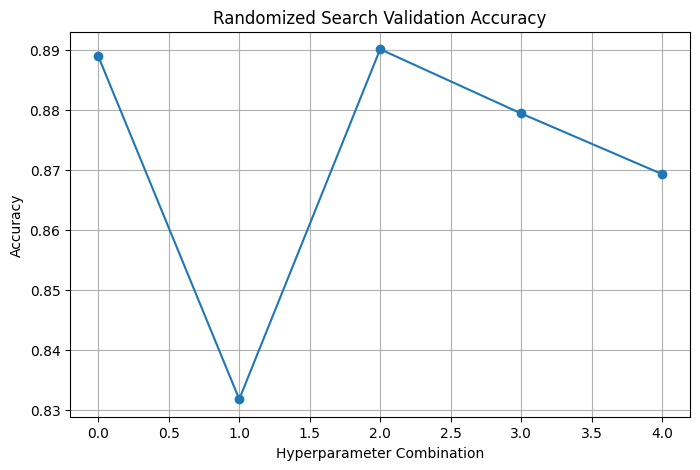

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt


results = pd.DataFrame(
    random_search.cv_results_
)


plt.figure(figsize=(8,5))

plt.plot(
    results["mean_test_score"],
    marker="o"
)


plt.title(
    "Randomized Search Validation Accuracy"
)

plt.xlabel(
    "Hyperparameter Combination"
)

plt.ylabel(
    "Accuracy"
)

plt.grid()

plt.show()

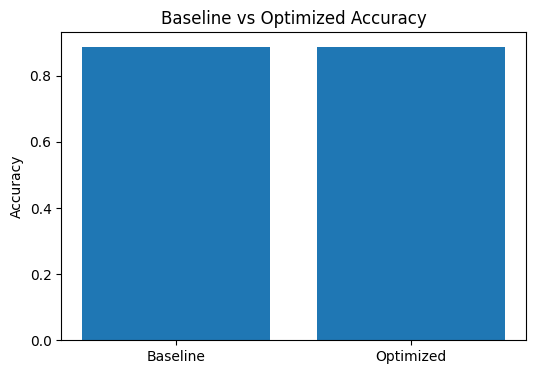

In [ ]:
models = [
    "Baseline",
    "Optimized"
]


accuracy = [
    0.8871,
    optimized_accuracy
]


plt.figure(figsize=(6,4))

plt.bar(
    models,
    accuracy
)

plt.title(
    "Baseline vs Optimized Accuracy"
)

plt.ylabel(
    "Accuracy"
)

plt.show()

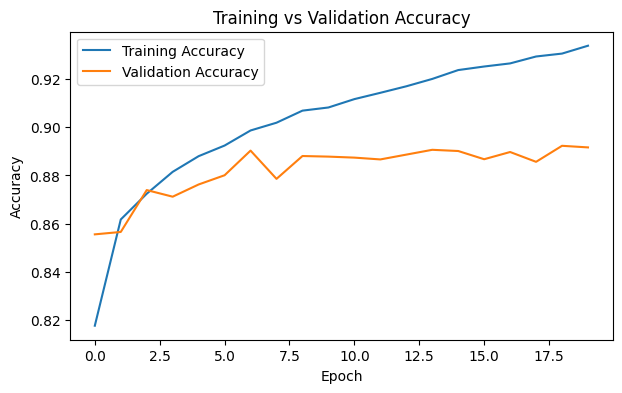

In [ ]:
plt.figure(figsize=(7,4))

plt.plot(
    history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)


plt.title("Training vs Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend()

plt.show()

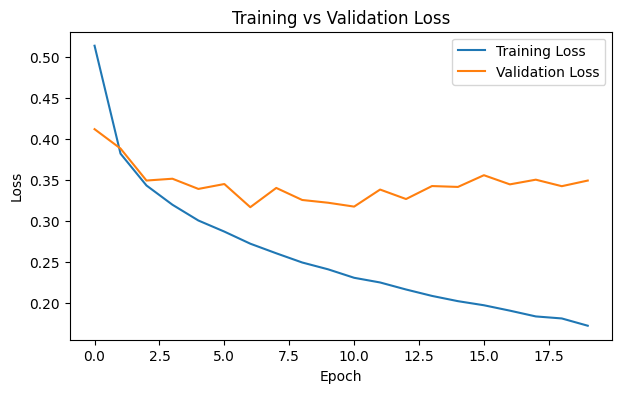

In [ ]:
plt.figure(figsize=(7,4))


plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)


plt.title("Training vs Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend()

plt.show()

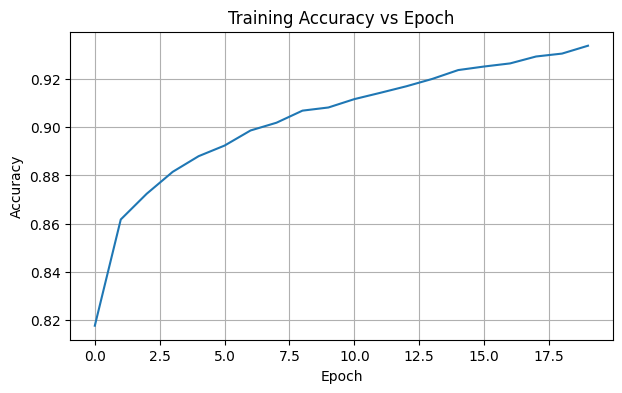

In [ ]:
plt.figure(figsize=(7,4))

plt.plot(history.history['accuracy'])

plt.title("Training Accuracy vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.grid()
plt.show()

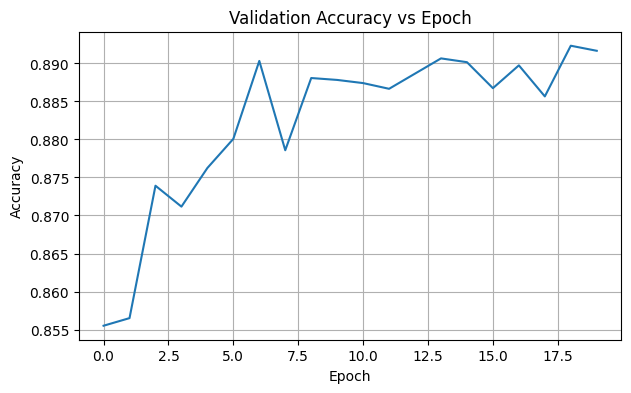

In [ ]:
plt.figure(figsize=(7,4))

plt.plot(history.history['val_accuracy'])

plt.title("Validation Accuracy vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.grid()
plt.show()

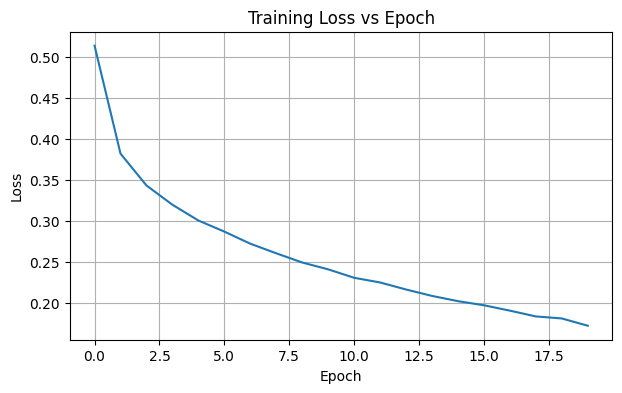

In [ ]:
plt.figure(figsize=(7,4))

plt.plot(history.history['loss'])

plt.title("Training Loss vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.grid()
plt.show()

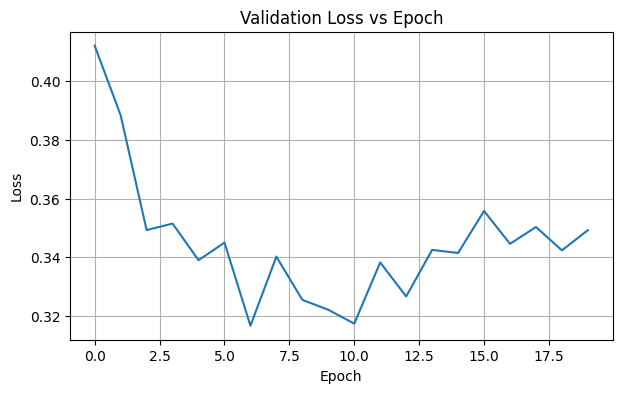

In [ ]:
plt.figure(figsize=(7,4))

plt.plot(history.history['val_loss'])

plt.title("Validation Loss vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.grid()
plt.show()

PERCEPTRON LEARNING ALGORITHM FOR THE XOR GATE
Initial random weights [bias, w1, w2] : [-0.2509  0.9014  0.464 ]

Update No       : 1
Epoch           : 1
Input Sample    : [1 1]
Target Output   : 0
Predicted Output: 1
Error           : -1
Old Weights     : [b=-0.2509, w1=0.9014, w2=0.4640]
New Weights     : [b=-0.3509, w1=0.8014, w2=0.3640]
Bias Update     : -0.2509 -> -0.3509 (delta = -0.1000)

--- End of Epoch 1: 1 misclassification(s) ---

Update No       : 2
Epoch           : 2
Input Sample    : [1 1]
Target Output   : 0
Predicted Output: 1
Error           : -1
Old Weights     : [b=-0.3509, w1=0.8014, w2=0.3640]
New Weights     : [b=-0.4509, w1=0.7014, w2=0.2640]
Bias Update     : -0.3509 -> -0.4509 (delta = -0.1000)

--- End of Epoch 2: 1 misclassification(s) ---

Update No       : 3
Epoch           : 3
Input Sample    : [0 1]
Target Output   : 1
Predicted Output: 0
Error           : +1
Old Weights     : [b=-0.4509, w1=0.7014, w2=0.2640]
New Weights     : [b=-0.3509, w1=0.7014, w2

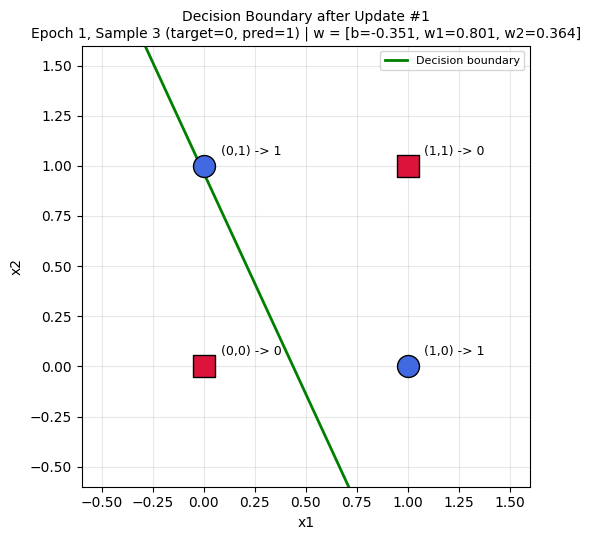


--- MIDDLE UPDATE (Update #23) ---


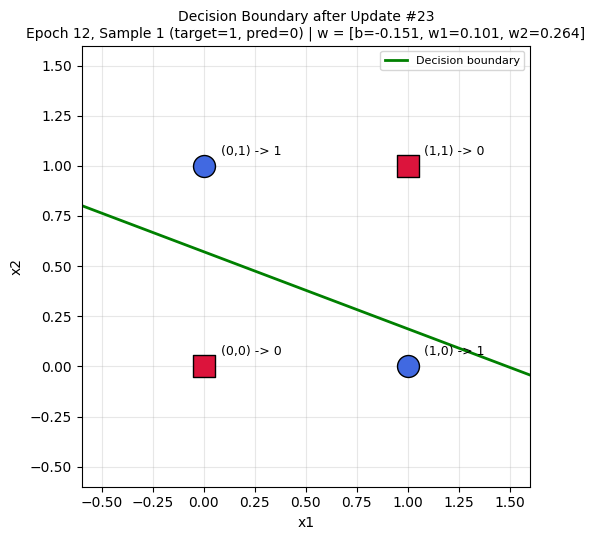


--- LATER UPDATE (Update #35) ---


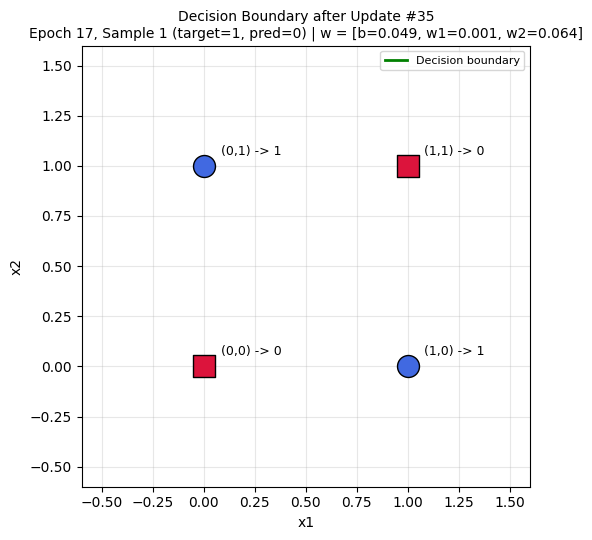


--- FINAL UPDATE (Update #47) ---


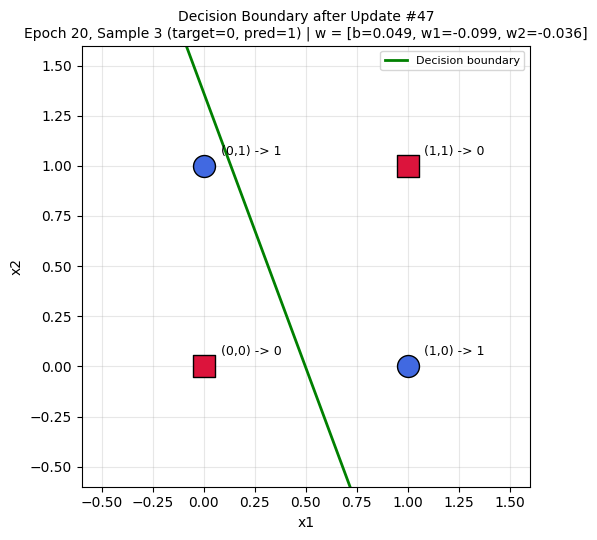


FINAL PREDICTION TABLE (using final trained weights)
Input     Target    Prediction  
--------------------------------
[0 0]     0         1           WRONG
[0 1]     1         1           OK
[1 0]     1         0           WRONG
[1 1]     0         0           OK
--------------------------------
Correctly classified: 2 / 4


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

X = np.array([[0, 0],
              [0, 1],
              [1, 0],
              [1, 1]])
y = np.array([0, 1, 1, 0])

X_bias = np.hstack([np.ones((X.shape[0], 1)), X])

LR = 0.1
MAX_EPOCHS = 20

weights = np.random.uniform(-1, 1, size=3)

print("=" * 65)
print("PERCEPTRON LEARNING ALGORITHM FOR THE XOR GATE")
print("=" * 65)
print("Initial random weights [bias, w1, w2] :", np.round(weights, 4))
print("=" * 65)

def step(v):
    """Threshold / step activation function."""
    return 1 if v >= 0 else 0


def predict(x_row, w):
    """Predict the perceptron output for one bias-augmented input row."""
    return step(np.dot(w, x_row))


def plot_decision_boundary(w, update_no, epoch, sample_idx, target, pred,
                            save_name=None):
    """
    Plot the 4 XOR points and the current perceptron decision boundary.
    Displays the plot directly (plt.show) as required for Colab/Jupyter.
    Optionally also saves the figure for inclusion in the lab report.
    """
    plt.figure(figsize=(5.5, 5.5))

    for i, point in enumerate(X):
        colour = "royalblue" if y[i] == 1 else "crimson"
        marker = "o" if y[i] == 1 else "s"
        plt.scatter(point[0], point[1], c=colour, marker=marker,
                    s=250, edgecolors="black", zorder=3)
        plt.annotate(f"({point[0]},{point[1]}) -> {y[i]}",
                    (point[0], point[1]),
                    textcoords="offset points", xytext=(12, 8), fontsize=9)
    x_vals = np.linspace(-0.6, 1.6, 200)
    b, w1, w2 = w
    if abs(w2) > 1e-8:
        y_vals = -(b + w1 * x_vals) / w2
        plt.plot(x_vals, y_vals, "g-", linewidth=2, label="Decision boundary")
    elif abs(w1) > 1e-8:
        x_line = -b / w1
        plt.axvline(x_line, color="g", linewidth=2, label="Decision boundary")
    else:
        plt.text(0.5, 0.5, "No valid boundary\n(all weights ~ 0)",
                ha="center", va="center", fontsize=10, color="green")

    plt.xlim(-0.6, 1.6)
    plt.ylim(-0.6, 1.6)
    plt.xlabel("x1")
    plt.ylabel("x2")
    title = (f"Decision Boundary after Update #{update_no}\n"
            f"Epoch {epoch}, Sample {sample_idx} (target={target}, pred={pred}) | "
            f"w = [b={b:.3f}, w1={w1:.3f}, w2={w2:.3f}]")
    plt.title(title, fontsize=10)
    plt.grid(alpha=0.3)
    plt.legend(loc="upper right", fontsize=8)
    plt.tight_layout()

    if save_name is not None:
        plt.savefig(save_name, dpi=110)
    plt.show()

update_log = []
update_count = 0
errors_per_epoch = []
converged = False

for epoch in range(1, MAX_EPOCHS + 1):
    epoch_errors = 0
    for i in range(len(X_bias)):
        x_i = X_bias[i]
        target = y[i]
        pred = predict(x_i, weights)
        error = target - pred

        if error != 0:
            old_weights = weights.copy()
            old_bias = old_weights[0]
            weights = weights + LR * error * x_i
            new_bias = weights[0]

            update_count += 1
            epoch_errors += 1

            print(f"\nUpdate No       : {update_count}")
            print(f"Epoch           : {epoch}")
            print(f"Input Sample    : {X[i]}")
            print(f"Target Output   : {target}")
            print(f"Predicted Output: {pred}")
            print(f"Error           : {error:+d}")
            print(f"Old Weights     : [b={old_weights[0]:.4f}, "
                f"w1={old_weights[1]:.4f}, w2={old_weights[2]:.4f}]")
            print(f"New Weights     : [b={weights[0]:.4f}, "
                f"w1={weights[1]:.4f}, w2={weights[2]:.4f}]")
            print(f"Bias Update     : {old_bias:.4f} -> {new_bias:.4f} "
                f"(delta = {new_bias - old_bias:+.4f})")

            update_log.append({
                "update_no": update_count,
                "epoch": epoch,
                "sample_idx": i,
                "input": X[i].copy(),
                "target": target,
                "pred": pred,
                "error": error,
                "old_weights": old_weights,
                "new_weights": weights.copy(),
            })

    errors_per_epoch.append(epoch_errors)
    print(f"\n--- End of Epoch {epoch}: {epoch_errors} misclassification(s) ---")

    if epoch_errors == 0:
        converged = True
        print(f"\nPerceptron CONVERGED after {epoch} epochs.")
        break

if not converged:
    print("\n" + "=" * 65)
    print(f"Perceptron DID NOT CONVERGE within {MAX_EPOCHS} epochs.")
    print(f"Total weight updates performed: {update_count}")
    print("=" * 65)

total_updates = update_count

first_idx = 1
middle_idx = max(1, total_updates // 2)
later_idx = max(1, int(total_updates * 0.75))
final_idx = total_updates

selected_updates = sorted(set([first_idx, middle_idx, later_idx, final_idx]))

labels_map = {
    first_idx: "FIRST",
    middle_idx: "MIDDLE",
    later_idx: "LATER",
    final_idx: "FINAL",
}

print("\n" + "=" * 65)
print("DECISION BOUNDARY PLOTS AT SELECTED UPDATES")
print(f"Selected update numbers: {selected_updates}")
print("=" * 65)

for entry in update_log:
    if entry["update_no"] in selected_updates:
        tag = labels_map.get(entry["update_no"], "")
        print(f"\n--- {tag} UPDATE (Update #{entry['update_no']}) ---")
        plot_decision_boundary(
            entry["new_weights"],
            entry["update_no"],
            entry["epoch"],
            entry["sample_idx"],
            entry["target"],
            entry["pred"],
            save_name=f"xor_decision_boundary_update_{entry['update_no']}.png"
        )
print("\n" + "=" * 65)
print("FINAL PREDICTION TABLE (using final trained weights)")
print("=" * 65)
print(f"{'Input':<10}{'Target':<10}{'Prediction':<12}")
print("-" * 32)

final_correct = 0
for i in range(len(X_bias)):
    pred = predict(X_bias[i], weights)
    correct = "OK" if pred == y[i] else "WRONG"
    if pred == y[i]:
        final_correct += 1
    print(f"{str(X[i]):<10}{y[i]:<10}{pred:<12}{correct}")

print("-" * 32)
print(f"Correctly classified: {final_correct} / 4")
print("=" * 65)

Final loss after 8000 epochs: 0.00038892705883634504
Final predictions:
[0 0] -> 0.0179
[0 1] -> 0.9794
[1 0] -> 0.9794
[1 1] -> 0.0197


/tmp/ipykernel_2171/4237042714.py:65: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  print(xi, "->", round(float(yi), 4))


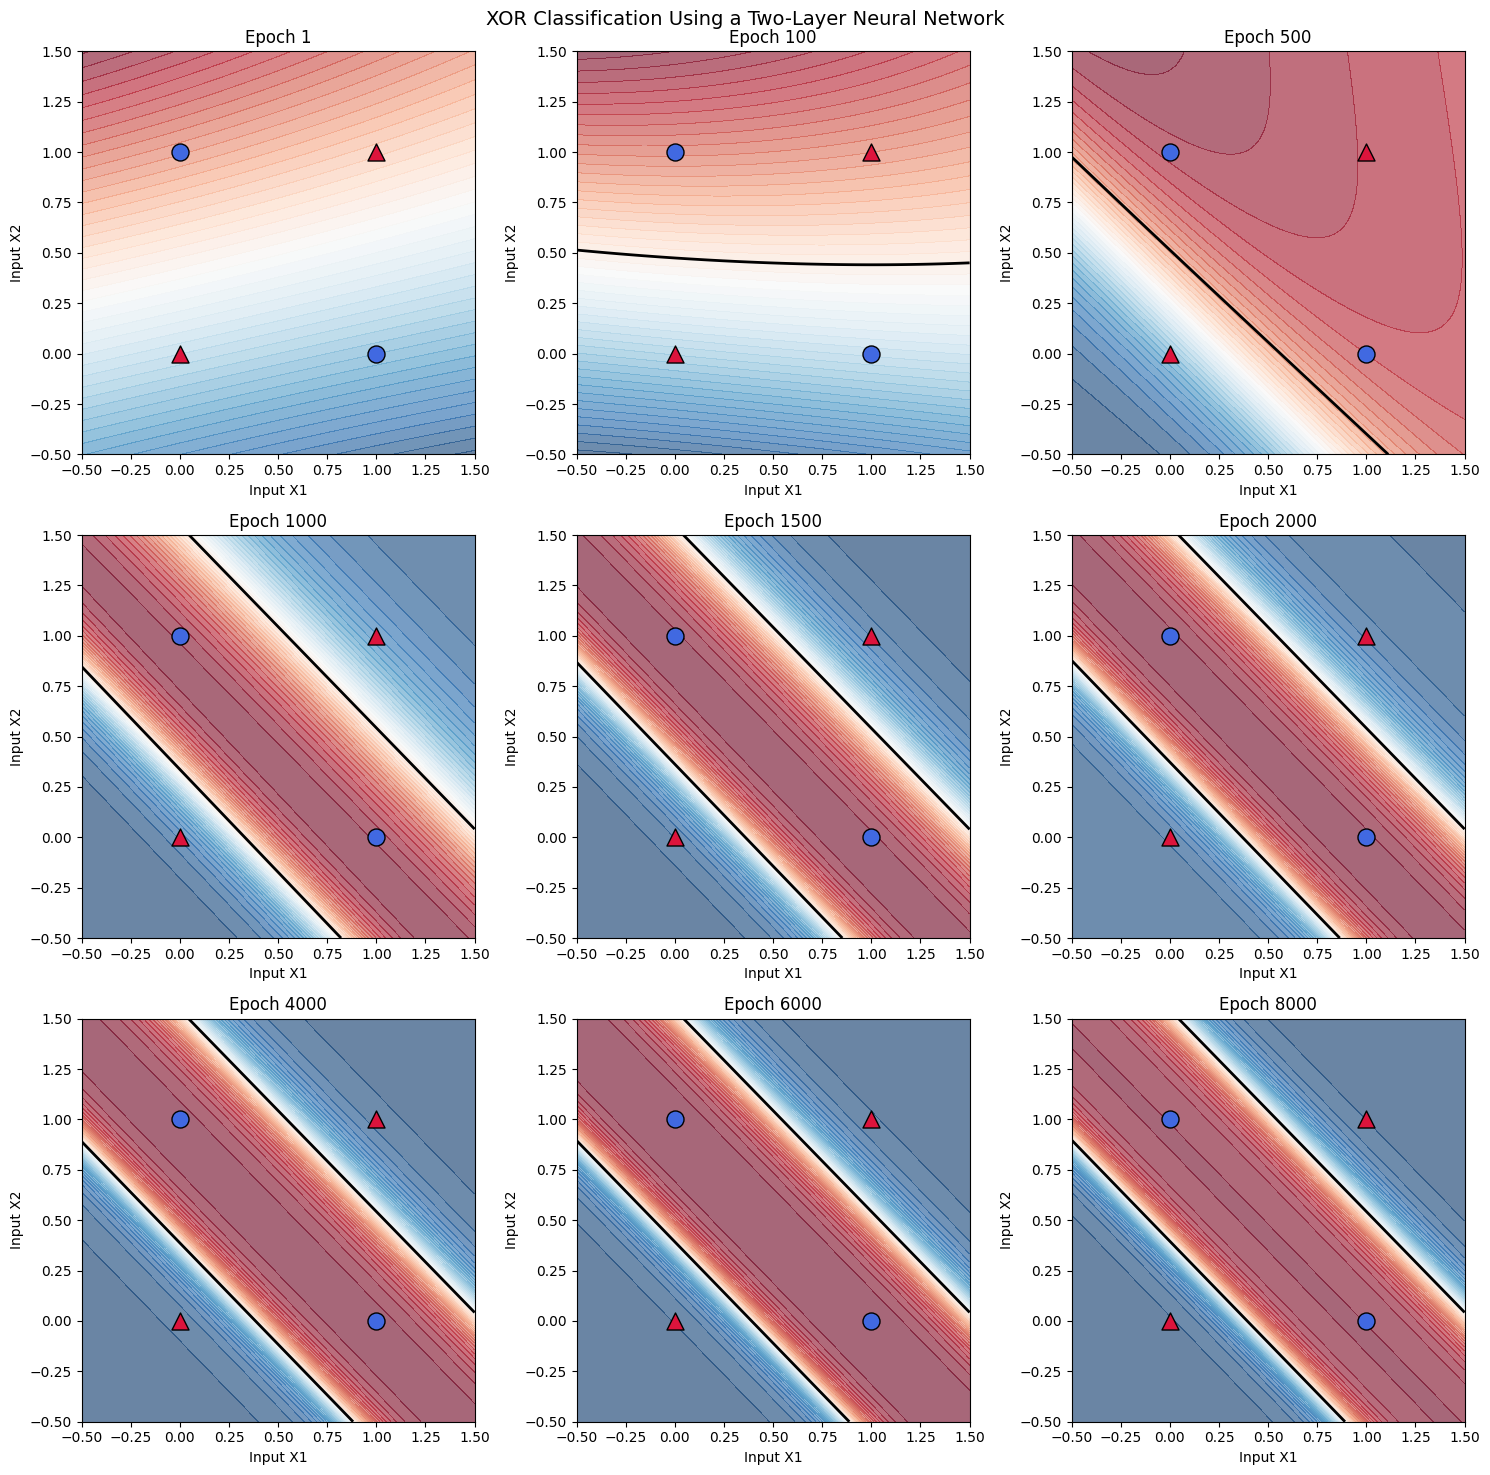

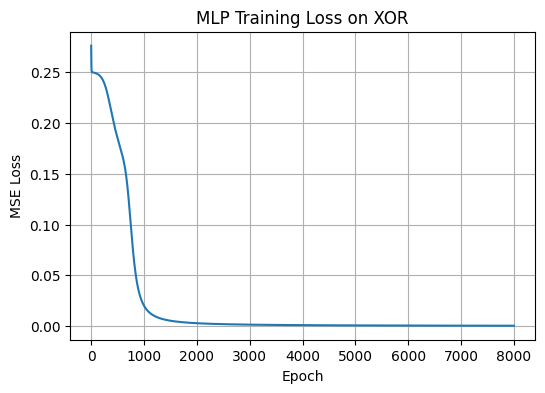

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# ---- XOR data ----
X = np.array([[0, 0],
              [0, 1],
              [1, 0],
              [1, 1]])
y = np.array([[0], [1], [1], [0]])

np.random.seed(1)

# ---- Network: 2 input -> 2 hidden -> 1 output ----
input_dim, hidden_dim, output_dim = 2, 2, 1

W1 = np.random.uniform(-1, 1, (input_dim, hidden_dim))
b1 = np.zeros((1, hidden_dim))
W2 = np.random.uniform(-1, 1, (hidden_dim, output_dim))
b2 = np.zeros((1, output_dim))

LR = 0.5
EPOCHS = 8000
snapshot_epochs = [1, 100, 500, 1000, 1500, 2000, 4000, 6000, 8000]
snapshots = {}

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def sigmoid_deriv(a):
    return a * (1 - a)

loss_history = []

for epoch in range(1, EPOCHS + 1):
    # ---- forward pass ----
    z1 = X @ W1 + b1
    a1 = sigmoid(z1)
    z2 = a1 @ W2 + b2
    a2 = sigmoid(z2)          # final prediction

    # ---- loss (MSE) ----
    error = y - a2
    loss = np.mean(error ** 2)
    loss_history.append(loss)

    # ---- backward pass ----
    d2 = error * sigmoid_deriv(a2)
    dW2 = a1.T @ d2
    db2 = np.sum(d2, axis=0, keepdims=True)

    d1 = (d2 @ W2.T) * sigmoid_deriv(a1)
    dW1 = X.T @ d1
    db1 = np.sum(d1, axis=0, keepdims=True)

    # ---- update ----
    W1 += LR * dW1; b1 += LR * db1
    W2 += LR * dW2; b2 += LR * db2

    if epoch in snapshot_epochs:
        snapshots[epoch] = (W1.copy(), b1.copy(), W2.copy(), b2.copy())

print("Final loss after 8000 epochs:", loss_history[-1])
print("Final predictions:")
for xi, yi in zip(X, a2):
    print(xi, "->", round(float(yi), 4))

# ---- plot decision boundary evolution ----
xx, yy = np.meshgrid(np.linspace(-0.5, 1.5, 300), np.linspace(-0.5, 1.5, 300))
grid = np.c_[xx.ravel(), yy.ravel()]

fig, axes = plt.subplots(3, 3, figsize=(15, 15))
fig.suptitle("XOR Classification Using a Two-Layer Neural Network", fontsize=14)

for ax, ep in zip(axes.ravel(), snapshot_epochs):
    W1s, b1s, W2s, b2s = snapshots[ep]
    a1g = sigmoid(grid @ W1s + b1s)
    a2g = sigmoid(a1g @ W2s + b2s).reshape(xx.shape)

    ax.contourf(xx, yy, a2g, levels=50, cmap="RdBu_r", alpha=0.6)
    ax.contour(xx, yy, a2g, levels=[0.5], colors="black", linewidths=2)
    for xi, yi in zip(X, y.ravel()):
        ax.scatter(*xi, c=("royalblue" if yi == 1 else "crimson"),
                   marker=("o" if yi == 1 else "^"), s=150,
                   edgecolors="black", zorder=3)
    ax.set_title(f"Epoch {ep}")
    ax.set_xlabel("Input X1"); ax.set_ylabel("Input X2")

plt.tight_layout()
plt.savefig("xor_mlp_decision_boundary.png", dpi=150)
plt.show()

# ---- loss curve ----
plt.figure(figsize=(6, 4))
plt.plot(loss_history)
plt.title("MLP Training Loss on XOR")
plt.xlabel("Epoch"); plt.ylabel("MSE Loss")
plt.grid(True)
plt.savefig("xor_mlp_loss.png", dpi=150)
plt.show()